In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/cifar-10/trainLabels.csv
/kaggle/input/competitions/cifar-10/sampleSubmission.csv
/kaggle/input/competitions/cifar-10/test.7z
/kaggle/input/competitions/cifar-10/train.7z


In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [3]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

In [4]:
train_dataset = datasets.CIFAR10(root='./data',\
              train=True, download=True, transform=transform)
dataloader = torch.utils.data.DataLoader(train_dataset, \
                                batch_size=32, shuffle=True)

100%|██████████| 170M/170M [1:03:13<00:00, 44.9kB/s] 


# Hyperparameters

In [5]:
latent_dim = 100
lr_D = 4e-4
lr_G = 1e-4
beta1 = 0.5
beta2 = 0.999
num_epochs = 100

# Building the Generator

## Note that this generator just for 3x32x32 img

In [19]:
class Generator(nn.Module):
    def __init__(self, latent_dim):
        super(Generator, self).__init__()
        self.model = nn.Sequential(
            # Input: latent_dim x 1 x 1 -> 4x4
            nn.ConvTranspose2d(latent_dim, 256, kernel_size=4, stride=1, padding=0, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(True),
            
            # 4x4 -> 8x8
            nn.ConvTranspose2d(256, 128, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(True),
            
            # 8x8 -> 16x16
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(True),
            
            # 16x16 -> 32x32
            nn.ConvTranspose2d(64, 3, kernel_size=4, stride=2, padding=1, bias=False),
            nn.Tanh()
        )

    def forward(self, x):
        if x.dim() == 2:
            x = x.unsqueeze(-1).unsqueeze(-1) # (B, latent_dim, 1, 1)
        return self.model(x).float()


In [22]:
g = Generator(1000)
a = torch.rand(32,1000)
g(a).shape

torch.Size([32, 3, 32, 32])

# Discriminator

In [23]:
class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()

        self.model = nn.Sequential(
        nn.Conv2d(3, 32, kernel_size=3, stride=2, padding=1),
        nn.LeakyReLU(0.2),
        nn.Dropout(0.25),
        nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1),
        nn.ZeroPad2d((0, 1, 0, 1)),
        nn.BatchNorm2d(64, momentum=0.82),
        nn.LeakyReLU(0.25),
        nn.Dropout(0.25),
        nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1),
        nn.BatchNorm2d(128, momentum=0.82),
        nn.LeakyReLU(0.2),
        nn.Dropout(0.25),
        nn.Conv2d(128, 256, kernel_size=3, stride=1, padding=1),
        nn.BatchNorm2d(256, momentum=0.8),
        nn.LeakyReLU(0.25),
        nn.Dropout(0.25),
        nn.Flatten(),
        nn.Linear(256 * 5 * 5, 1),
        nn.Sigmoid()
    )

    def forward(self, img):
        return self.model(img)

In [24]:
D = Discriminator()
img = torch.rand(100,3,32,32)
D(img).shape

torch.Size([100, 1])

In [25]:
generator = Generator(latent_dim)
generator.to(device)
discriminator = Discriminator()
discriminator.to(device)
optimizer_g = optim.AdamW(generator.parameters(),betas = [beta1,beta2],lr = lr_G)
optimizer_d = optim.AdamW(discriminator.parameters(),betas = [beta1,beta2],lr = lr_D)
loss = nn.BCELoss()
lb_param = 0.1


### Misunderstanding: The generator create the fake_img, not the noise for plus to real_img.

In [11]:
def set_requires_grad(model, requires_grad=True):
    for p in model.parameters():
        p.requires_grad = requires_grad

In [32]:
from tqdm import tqdm

def train():
    criterion = torch.nn.BCELoss() 

    for epoch in tqdm(range(num_epochs)):
        loss_g = 0.0
        loss_d = 0.0
        
        for i, (real_img, targets) in enumerate(dataloader):
            b = real_img.shape[0]
            
            real_img = real_img.to(device)
            real = torch.full((b, 1),0.9,dtype = torch.float).to(device) # Label smoothing
            fake = torch.full((b, 1), 0,dtype = torch.float).to(device)
            
            noise = torch.randn(b, latent_dim).to(device) # Note: torch.randn is standard for GANs
            
            # ---------------------
            #  Train Discriminator
            # ---------------------
            optimizer_d.zero_grad()
            set_requires_grad(discriminator,True)
            
            # Generate fake images ONCE
            fake_img = generator(noise)
            
            real_loss = criterion(discriminator(real_img), real)
            fake_loss = criterion(discriminator(fake_img.detach()), fake)
            
            D_loss = (real_loss + fake_loss) / 2
            D_loss.backward()
            optimizer_d.step()

            # -----------------
            #  Train Generator
            # -----------------
            set_requires_grad(discriminator, False)
            optimizer_g.zero_grad()
            
            G_loss = criterion(discriminator(fake_img), real) 
            
            G_loss.backward()
            optimizer_g.step()

            loss_g += G_loss.item()
            loss_d += D_loss.item()

        print(f"Epoch [{epoch+1}/{num_epochs}] | Generator Loss: {loss_g / len(dataloader):.4f} | Discriminator Loss: {loss_d / len(dataloader):.4f}")

In [33]:
train()

  1%|          | 1/100 [00:26<44:04, 26.71s/it]

Epoch [1/100] | Generator Loss: 3.4651 | Discriminator Loss: 0.3286


  2%|▏         | 2/100 [00:52<42:38, 26.10s/it]

Epoch [2/100] | Generator Loss: 2.8178 | Discriminator Loss: 0.3715


  3%|▎         | 3/100 [01:18<42:08, 26.06s/it]

...

Epoch [98/100] | Generator Loss: 2.1997 | Discriminator Loss: 0.4133


 99%|█████████▉| 99/100 [42:39<00:25, 25.86s/it]

Epoch [99/100] | Generator Loss: 2.2080 | Discriminator Loss: 0.4119


100%|██████████| 100/100 [43:05<00:00, 25.86s/it]

Epoch [100/100] | Generator Loss: 2.1932 | Discriminator Loss: 0.4247


# Inference, Generating some img

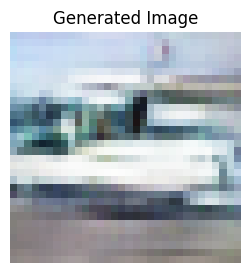

In [92]:
import matplotlib.pyplot as plt

def inference():
    generator.eval()
    with torch.no_grad():
        noise = torch.randn(1, latent_dim).to(device)
        
        # 2. Sinh ảnh
        img_tensor = generator(noise).squeeze(0).cpu() # Dải [-1, 1]
        img_output = (img_tensor * 0.5 + 0.5).clamp(0, 1).numpy()
        img_output = img_output.transpose(1, 2, 0)
        
        plt.figure(figsize=(3, 3))
        plt.imshow(img_output)
        plt.axis("off")
        plt.title("Generated Image")
        plt.show()

inference()